In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Regresión logística para detección de fraude en transacciones financieras

El objetivo de este laboratorio es construir un modelo de **regresión logística** que clasifique transacciones como fraudulentas o legítimas, utilizando el dataset de transacciones financieras almacenado en AWS S3. En este contexto, se explorarán y preprocesarán los datos, se entrenará el modelo con `scikit-learn` y se evaluará su desempeño mediante métricas como **precisión** y **recall**.

In [2]:
# URL del archivo en el bucket público de AWS
url = "https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv"
df  = pd.read_csv(url)

In [3]:
# Visualizar las primeras filas del DataFrame
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Número total de observaciones en el dataset
print(f"Total de observaciones: {len(df):,}")

Total de observaciones: 6,362,620


El dataset contiene **6,362,620 observaciones**, convirtiéndolo en un conjunto de datos de gran escala. A continuación, se realiza una exploración detallada para comprender la estructura y distribución de las variables.

## Exploración del dataset

In [5]:
# Exploración inicial del dataset
print(f"Dimensiones: {df.shape[0]:,} observaciones, {df.shape[1]} columnas")
print(f"Valores faltantes: {df.isnull().sum().sum()}")
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nDistribución de la variable objetivo (isFraud):")
conteo_fraude = df['isFraud'].value_counts()
print(f"  Legítimas (0): {conteo_fraude[0]:,} ({conteo_fraude[0]/len(df)*100:.2f}%)")
print(f"  Fraude (1):    {conteo_fraude[1]:,} ({conteo_fraude[1]/len(df)*100:.2f}%)")
print(f"\nTipos de transacción:")
print(df['type'].value_counts())

Dimensiones: 6,362,620 observaciones, 11 columnas


Valores faltantes: 0

Tipos de datos:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Distribución de la variable objetivo (isFraud):
  Legítimas (0): 6,354,407 (99.87%)
  Fraude (1):    8,213 (0.13%)

Tipos de transacción:


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


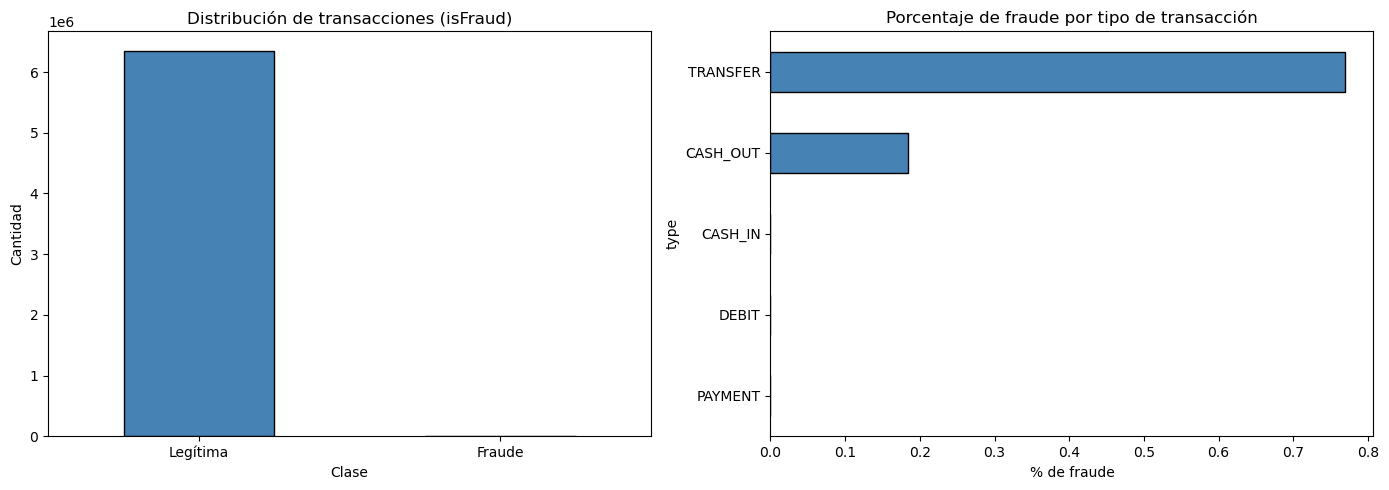

In [6]:
# Visualización del desbalance de clases y fraude por tipo de transacción
figura, ejes = plt.subplots(1, 2, figsize = (14, 5))

# Distribución de la variable objetivo
etiquetas_fraude = ['Legítima', 'Fraude']
colores          = ['steelblue', 'coral']
df['isFraud'].value_counts().plot(
    kind      = 'bar',
    ax        = ejes[0],
    color     = colores,
    edgecolor = 'black',
)
ejes[0].set_title('Distribución de transacciones (isFraud)')
ejes[0].set_xlabel('Clase')
ejes[0].set_ylabel('Cantidad')
ejes[0].set_xticklabels(etiquetas_fraude, rotation = 0)

# Fraude por tipo de transacción
fraude_tipo = df.groupby('type')['isFraud'].mean() * 100
fraude_tipo.sort_values(ascending = False).plot(
    kind      = 'barh',
    ax        = ejes[1],
    color     = 'steelblue',
    edgecolor = 'black',
)
ejes[1].set_title('Porcentaje de fraude por tipo de transacción')
ejes[1].set_xlabel('% de fraude')
ejes[1].invert_yaxis()

plt.tight_layout()
plt.show()

En este caso, se trata de un dataset masivo con más de 6 millones de transacciones. La clase objetivo (`isFraud`) está **altamente desbalanceada**; a saber, el 99.87% de las transacciones son legítimas y solo el 0.13% corresponde a fraudes. El desbalance es característico de problemas reales de detección de fraude y requiere atención especial durante el modelado para evitar que el clasificador ignore la clase minoritaria.

Además, se lograron identificar cinco tipos de transacciones: `CASH_OUT`, `PAYMENT`, `CASH_IN`, `TRANSFER` y `DEBIT`. Al respecto, resulta necesario analizar en cuáles de estos tipos se concentra la actividad fraudulenta.

## Preprocesamiento de datos

In [7]:
# Analizar en qué tipos de transacción ocurre el fraude
fraude_por_tipo = df.groupby('type')['isFraud'].sum()
print("Fraudes por tipo de transacción:")
print(fraude_por_tipo)
print("\nEl fraude solo ocurre en transacciones TRANSFER y CASH_OUT.")

Fraudes por tipo de transacción:
type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

El fraude solo ocurre en transacciones TRANSFER y CASH_OUT.


In [8]:
# Filtrar solo transacciones TRANSFER y CASH_OUT (donde ocurre fraude)
df_filtrado = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print(f"Transacciones después del filtro: {len(df_filtrado):,}")

# Codificar la variable 'type' (TRANSFER = 1, CASH_OUT = 0)
df_filtrado['type_encoded'] = (df_filtrado['type'] == 'TRANSFER').astype(int)

# Crear variable de diferencia de balance (origen y destino)
df_filtrado['diff_balance_orig'] = df_filtrado['newbalanceOrig'] - df_filtrado['oldbalanceOrg']
df_filtrado['diff_balance_dest'] = df_filtrado['newbalanceDest'] - df_filtrado['oldbalanceDest']

# Seleccionar variables predictoras
columnas_predictoras = [
    'type_encoded',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'diff_balance_orig',
    'diff_balance_dest'
]

X = df_filtrado[columnas_predictoras]
y = df_filtrado['isFraud']

print(f"\nVariables predictoras seleccionadas: {len(columnas_predictoras)}")
print(f"Distribución después del filtro:")
print(f"  Legítimas: {(y == 0).sum():,}")
print(f"  Fraude:    {(y == 1).sum():,}")

Transacciones después del filtro: 2,770,409

Variables predictoras seleccionadas: 8
Distribución después del filtro:
  Legítimas: 2,762,196
  Fraude:    8,213


Ahora bien, filtré únicamente las transacciones de tipo `TRANSFER` y `CASH_OUT`, ya que son las únicas donde se registran fraudes. Después, eliminé las columnas categóricas de nombres (`nameOrig`, `nameDest`) y las variables no informativas (`step`, `isFlaggedFraud`). Adicionalmente, creé dos **variables derivadas** que capturan el cambio neto en los balances:

- `diff_balance_orig`: Diferencia entre el balance final e inicial del origen.
- `diff_balance_dest`: Diferencia entre el balance final e inicial del destino.

Dichas variables son relevantes porque las transacciones fraudulentas suelen vaciar la cuenta de origen y acumular fondos en la cuenta destino.

## División del dataset, escalado y entrenamiento

In [9]:
# División en 80% entrenamiento y 20% prueba
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y,
)

print(f"Conjunto de entrenamiento: {X_entrenamiento.shape[0]:,} observaciones")
print(f"Conjunto de prueba:        {X_prueba.shape[0]:,} observaciones")

# Escalar las variables con StandardScaler
escalador                = StandardScaler()
X_entrenamiento_escalado = escalador.fit_transform(X_entrenamiento)
X_prueba_escalado        = escalador.transform(X_prueba)

print("\nDatos escalados correctamente.")

Conjunto de entrenamiento: 2,216,327 observaciones
Conjunto de prueba:        554,082 observaciones



Datos escalados correctamente.


In [10]:
# Entrenar el modelo de regresión logística
# class_weight='balanced' compensa el desbalance de clases
modelo_logistico = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    random_state = 42,
    solver       = 'lbfgs',
)
modelo_logistico.fit(X_entrenamiento_escalado, y_entrenamiento)

# Predicciones sobre el conjunto de prueba
predicciones = modelo_logistico.predict(X_prueba_escalado)

print("Modelo de regresión logística entrenado correctamente.")

Modelo de regresión logística entrenado correctamente.


En este punto, utilicé `class_weight='balanced'` para que el modelo asigne mayor peso a la clase minoritaria (fraude), compensando así el desbalance severo del dataset. Lo anterior resulta fundamental para que el modelo no ignore los casos de fraude y optimice el recall. Además, apliqué `StandardScaler` para normalizar las variables antes del entrenamiento, ya que la regresión logística es sensible a la escala de las características.

## Evaluación del modelo

Evalúo el desempeño del modelo con las siguientes métricas:

- **Exactitud (Accuracy):** Proporción total de predicciones correctas.
- **Precisión (Precision):** De las transacciones marcadas como fraude, qué proporción realmente lo es.
- **Recall (Sensibilidad):** De los fraudes reales, qué proporción fue detectada por el modelo.
- **F1-Score:** Media armónica entre precisión y recall.

En detección de fraude, el **recall** es la métrica prioritaria (es preferible investigar falsas alarmas a dejar pasar fraudes sin detectar).

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# Métricas de evaluación
exactitud  = accuracy_score(y_prueba, predicciones)
precision  = precision_score(y_prueba, predicciones)
recall     = recall_score(y_prueba, predicciones)
f1         = f1_score(y_prueba, predicciones)

print("=" * 55)
print("EVALUACIÓN FINAL DEL MODELO - REGRESIÓN LOGÍSTICA")
print("=" * 55)
print(f"\n  Exactitud (Accuracy):   {exactitud:.4f}")
print(f"  Precisión (Precision):  {precision:.4f}")
print(f"  Recall (Sensibilidad):  {recall:.4f}")
print(f"  F1-Score:               {f1:.4f}")
print(f"\n{'=' * 55}")

print("\nReporte de clasificación completo:")
print(classification_report(
    y_prueba,
    predicciones,
    target_names = ['Legítima', 'Fraude'],
))

EVALUACIÓN FINAL DEL MODELO - REGRESIÓN LOGÍSTICA

  Exactitud (Accuracy):   0.9349
  Precisión (Precision):  0.0387
  Recall (Sensibilidad):  0.8795
  F1-Score:               0.0742


Reporte de clasificación completo:


              precision    recall  f1-score   support

    Legítima       1.00      0.94      0.97    552439
      Fraude       0.04      0.88      0.07      1643

    accuracy                           0.93    554082
   macro avg       0.52      0.91      0.52    554082
weighted avg       1.00      0.93      0.96    554082



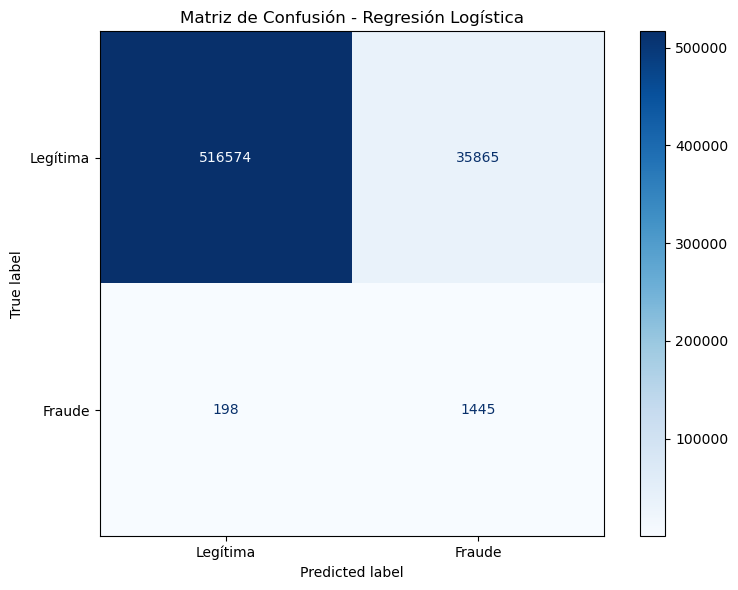

Verdaderos negativos (legítimas correctas): 516,574
Falsos positivos (legítimas como fraude):   35,865
Falsos negativos (fraudes no detectados):   198
Verdaderos positivos (fraudes detectados):  1,445


In [12]:
# Matriz de confusión
figura, eje = plt.subplots(figsize = (8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_prueba,
    predicciones,
    display_labels = ['Legítima', 'Fraude'],
    cmap           = 'Blues',
    ax             = eje,
)
eje.set_title('Matriz de Confusión - Regresión Logística')
plt.tight_layout()
plt.show()

# Desglose de la matriz de confusión
mc = confusion_matrix(y_prueba, predicciones)
print(f"Verdaderos negativos (legítimas correctas): {mc[0][0]:,}")
print(f"Falsos positivos (legítimas como fraude):   {mc[0][1]:,}")
print(f"Falsos negativos (fraudes no detectados):   {mc[1][0]:,}")
print(f"Verdaderos positivos (fraudes detectados):  {mc[1][1]:,}")

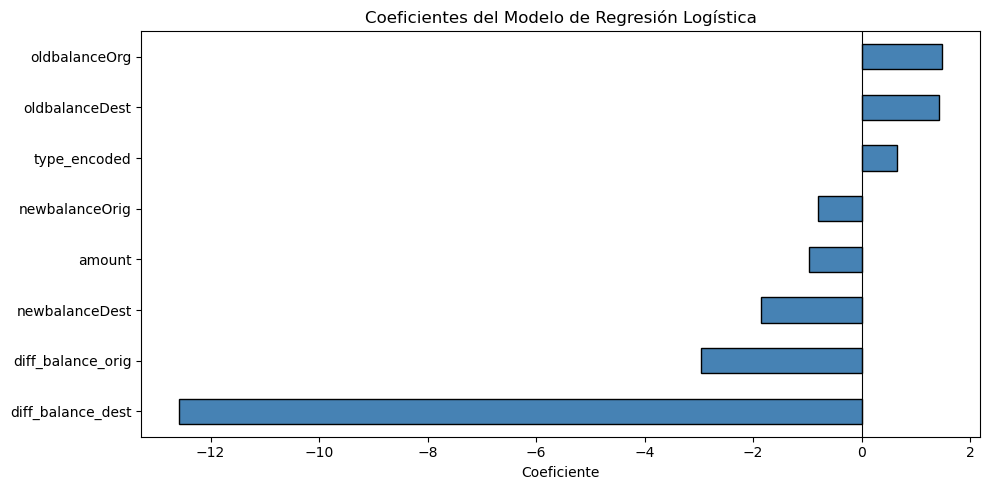

In [13]:
# Coeficientes del modelo
coeficientes = pd.Series(
    modelo_logistico.coef_[0],
    index = columnas_predictoras,
).sort_values(ascending = False)

figura, eje = plt.subplots(figsize = (10, 5))
coeficientes.plot(
                  kind      = 'barh',
                  color     = 'steelblue',
                  edgecolor = 'black',
                  ax        = eje)
eje.set_title('Coeficientes del Modelo de Regresión Logística')
eje.set_xlabel('Coeficiente')
eje.axvline(
            x         = 0,
            color     = 'black',
            linestyle = '-',
            linewidth = 0.8
           )
eje.invert_yaxis()
plt.tight_layout()
plt.show()

## Conclusiones

1. El modelo de regresión logística alcanza un **recall del $87.95\%$**, detectando $1,445.00$ de las $1,643.00$ transacciones fraudulentas en el conjunto de prueba. En este sentido, solo $198.00$ fraudes quedaron sin identificar, lo cual representa un desempeño sólido considerando el severo desbalance del dataset.

2. La **precisión baja ($3.87\%$)** es consecuencia directa del desbalance extremo ($0.13\%$ fraude vs $99.87\%$ legítimas) y del uso de `class_weight='balanced'`, que prioriza detectar fraudes a costa de generar falsos positivos. En un entorno bancario real, estas falsas alarmas serían investigadas por un equipo de análisis, lo cual es un costo aceptable frente al riesgo de no detectar fraudes.

3. Las variables más influyentes en la predicción de fraude son las relacionadas con los **cambios en los balances** de origen y destino, lo cual es consistente con el patrón típico de transacciones fraudulentas (vaciar la cuenta de origen y acumular fondos en la cuenta destino).

4. El modelo demuestra que incluso un enfoque lineal como la regresión logística puede ser efectivo para la detección de fraude.